# 读取WAY-EEG-GAL 数据集

In [1]:
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import numpy as np
import time 

## 加载数据(Holistic Structure,HS)

In [2]:
# 指定文件
structure = 'HS'    # 当前此文件只能 load HS
participant = 'P1'   # 受试
series = 'S1'        # 

In [3]:
file_path = f'{participant}/{structure}_{participant}_{series}.mat'
print(f'已加载的路径为：“{file_path}”')

已加载的路径为：“P1/HS_P1_S1.mat”


In [4]:
mat_data = sio.loadmat(file_path) 
#print('hs.type:',type(mat_data['hs']))
#print('len:',len(mat_data['hs'][0,0]))

## 重构数据

In [5]:
from dataclasses import dataclass, field
from typing import List, Optional

In [6]:
# 自定义数据类型，方便查看
@dataclass
class SignalModule:
    """通用信号模块（emg、eeg、kin 等共用）"""
    sig: np.ndarray                    # 信号矩阵
    names: List[str]                   # 通道名称
    samplingrate: int                  # 采样率
    tensor: Optional[torch.Tensor] = None   # 后续转为 PyTorch tensor

@dataclass
class HSData:
    """最顶层结构，对应 MATLAB 中的 hs"""
    name: str                 # 受试者名称
    participant: int          # 受试者编号
    series: int               # 系列编号
    emg: SignalModule         # emg 信号
    eeg: SignalModule         # eeg 信号
    kin: SignalModule         # kin 信号
    env: SignalModule         # env 环境信息
    misc: SignalModule        # misc 辅助信号

In [7]:
# data->hs的转换函数
def build_hs_data(mat_data) -> HSData:
    """data->hs的转换函数"""
    hs_struct = mat_data['hs'][0,0]
    # hs_struct 是 tuple of 5 structured arrays
    name, participant, series, emg_arr, eeg_arr, kin_arr, env_arr, misc_arr = hs_struct

    def extract_module(arr):
        """通用信号模块（emg、eeg、kin 等共用）的转换"""
        matches = {}    # 定义匹配字典
        target = arr[0,0]    
        # 遍历查找匹配项
        for i in [0, 1, 2]:
            elem_type = type(target[i][0,0])
            
            if elem_type in (np.float64, np.float32):    # sig
                matches['sig'] = target[i]
            elif elem_type == np.uint16:    # samplingrate
                matches['samplingrate'] = int(target[i][0,0].item())
            elif elem_type == np.ndarray and type(target[i][0,0][0]) == np.str_:    # names
                matches['names_array'] = target[i]
        # names_array转换names
        names = [str(name[0]) for name in matches['names_array'][0].tolist()]
        # 转为tensor
        sig=matches.get('sig')
        tensor = torch.from_numpy(sig.astype(np.float64))
        return SignalModule(
            sig=sig, 
            names=names, 
            samplingrate=matches.get('samplingrate'),
            tensor = tensor
        )
    
    return HSData(
        name=str(name[0]),
        participant=str(participant[0][0]),
        series=str(series[0][0]),
        emg=extract_module(emg_arr),
        eeg=extract_module(eeg_arr),
        kin=extract_module(kin_arr),
        env=extract_module(env_arr),
        misc=extract_module(misc_arr)
    )

In [8]:
hs = build_hs_data(mat_data)
# 使用示例
print(hs.emg.names)           # ['Anterior Deltoid', 'Brachoradial', ...]
print(hs.eeg.samplingrate)    # 500
print(hs.kin.sig.shape)       # (119496, 36)
print(hs.misc.names)    # torch.Size([119496, 2])

['Anterior Deltoid', 'Brachoradial', 'Flexor Digitorum', 'Common Extensor Digitorum', 'First Dorsal Interosseus']
500
(119496, 36)
['Button', 'Magnet', 'SurfaceLED', 'ParticipantLED', 'Temperature1', 'Temperature2']


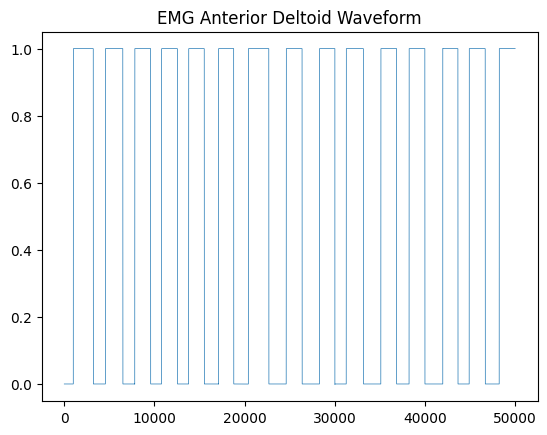

In [14]:
# 验证 tensor
plt.plot(hs.misc.tensor[:50000, 3], linewidth=0.5)  # 通道 0 波形
plt.title("EMG Anterior Deltoid Waveform")
plt.show()